# Modeling type of charts to represents concrete degrad

## Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Functions

In [14]:
def momento_resistente_secao_sem_cor(a_s: float, b_w: float, h: float, f_ck: float, f_yk: float = 500000, gamma_s: float = 1.15, gamma_c: float = 1.40) -> float:
    """
    Calcula o momento resistente para vigas de concreto armado.

    Args:
        a_s (float): Área da armadura longitudinal (mm²)
        b_w (float): Largura da seção transversal (mm)
        h (float): Altura total da seção transversal (mm)
        f_ck (float): Resistência característica à compressão do concreto (kPa)
        f_yk (float): Resistência característica do aço (kPa). Padrão: 500000
        gamma_s (float): Fator de segurança do aço. Padrão: 1.15
        gamma_c (float): Fator de segurança do concreto. Padrão: 1.40

    Returns:
        m_rd: valor do momento resistente limite utilizando armadura simples (N.mm)
    """

    """
    Transforms a vector of random variables from the X space to the Y space.

    :param x: Random variables in the X space.
    :param dneq1: D^-1 matrix.
    :param mu_neq: Mean matrix.
    
    :return: output [0] = Probability of failure values for each indicator function, 
                output[1] = beta_df: Reliability index values for each indicator function.
    """

    # Temporary conversion of f_ck to MPa to determine coefficients
    f_ck /= 1E3  # in MPa

    if f_ck > 50:
        lambdaa = 0.80 - ((f_ck - 50) / 400)
        alpha_c = (1.00 - ((f_ck - 50) / 200)) * 0.85
    else:
        lambdaa = 0.80
        alpha_c = 0.85

    f_ck *= 1E3
    # Convert f_ck back to kPa and calculate f_cd (design compressive strength)
    f_cd = f_ck / gamma_c

    # Effective depth of the section
    d = h * 0.90

    # Design yield strength of steel
    f_yd = f_yk / gamma_s

    # Depth of the neutral axis
    x = (a_s * f_yd) / (f_cd * b_w * alpha_c * lambdaa)

    # Calculation of the ultimate resisting moment
    m_rd = a_s * f_yd * (d - 0.5 * lambdaa * x)

    return m_rd


## Modeling

Load dataset

In [5]:
# File path to the Excel spreadsheet
file_path = r'D:\Documentos\ic_victor\final_df_tempo_limite_lhspequeno.xlsx'

# Read the entire Excel file
full_df = pd.read_excel(file_path)

# Select the first row (useful for initial testing or verification)
df = full_df.head(1)

# Display the selected DataFrame
print(df)


    b_w    h   f_ck      m_rd      m_gk      m_qk       a_s       time
0  0.14  0.3  20000  9.836582  6.323517  0.702613  0.000076  47.180765


In [6]:
#Define the number os samples
n = 20

In [17]:
# Initialize lists to store results for resisting moment and degraded steel area
results_mr = []
results_as = []

# Loop over each row in the DataFrame
for i, row in df.iterrows():
    # Extract input parameters from the DataFrame
    b_w = row['b_w']              # Section width (cm)
    h = row['h']                  # Section height (cm)
    f_ck = row['f_ck']            # Concrete compressive strength (kPa)
    f_yk = 500_000                # Characteristic steel yield strength (kPa)
    m_gk = row['m_gk']            # Dead load moment (N·cm)
    m_qk = row['m_qk']            # Live load moment (N·cm)
    a_s_initial = row['a_s']      # Initial steel area (cm²)

    # Monte Carlo simulations
    for j in range(n):
        m_r_list = []             # List to store resisting moments over time
        a_s_list = []             # List to store degraded steel area over time

        # Sample from normal distributions for concrete strength, steel yield strength, and dead load moment
        f_ck_sample = np.random.normal(f_ck, 0.12 * f_ck)
        f_yk_sample = np.random.normal(f_yk, 0.05 * f_yk)
        m_gk_sample = np.random.normal(1.06 * m_gk, 0.15 * 1.06 * m_gk)

        # Loop through each time step (e.g., years)
        for k in range(0, 101, 10):
            # Sample from a Gumbel distribution for live load moment
            m_qk_sample = np.random.gumbel(0.93 * m_qk, 0.25 * 0.93 * m_qk)

            # Define degradation factor for steel area
            if k < 39:
                degradation_factor = 1.0  # No degradation before year 39
            else:
                a_d = 1.0
                b_d = 0.000055
                degradation_factor = a_d * (1 - b_d * k**2)

            # Calculate degraded steel area
            a_s_degraded = a_s_initial * degradation_factor

            # Compute resisting moment using custom function
            m_r = momento_resistente_secao_sem_cor(a_s_degraded, b_w, h, f_ck_sample, f_yk_sample, gamma_s=1.00, gamma_c=1.00)

            # Store results at this time step
            m_r_list.append(m_r)
            a_s_list.append(a_s_degraded)

        # Store time series for this simulation
        results_mr.append(m_r_list)
        results_as.append(a_s_list)




Plots

- chart resistent bending moment

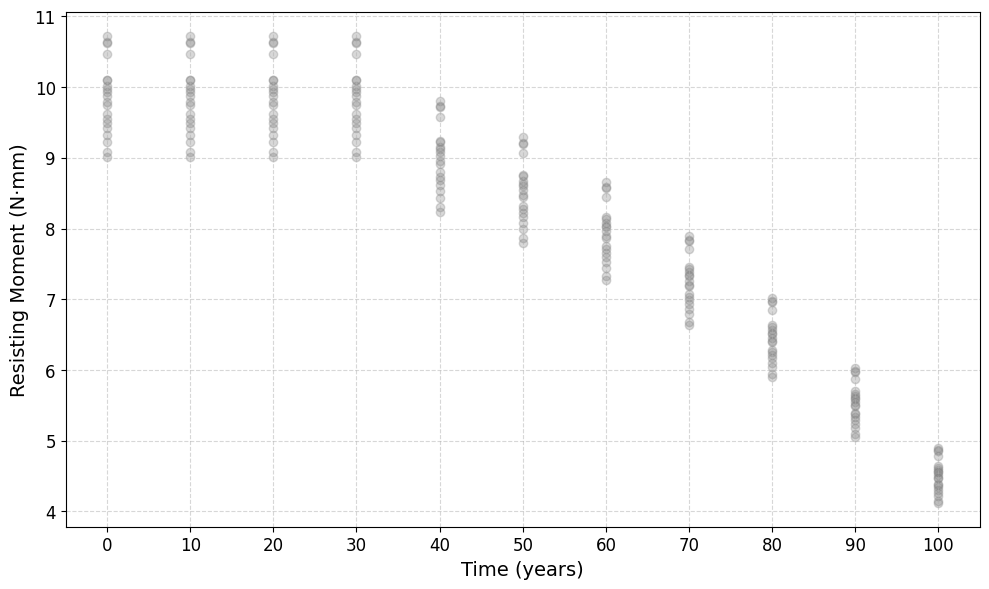

In [20]:
# Time steps (e.g., years or inspection intervals)
x = list(np.arange(0, 101, 10))

# Plotting resistant moment curves for each simulation
plt.figure(figsize=(10, 6))  # Set figure size (width x height in inches)

for m_r_curve in results_mr:
    # Plot each resistance curve
    plt.scatter(x, m_r_curve, marker='o', linestyle='-', color='gray', alpha=0.3)

# Plot formatting
plt.xlabel('Time (years)', fontsize=14)
plt.ylabel('Resisting Moment (N·mm)', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(x)
plt.tight_layout()

# Show the plot
plt.show()


- Chart steel reinforcement degrad

In [15]:
momento_resistente_secao_sem_cor(3E-4, 0.14, 0.30, 20000)

30.213499388413215

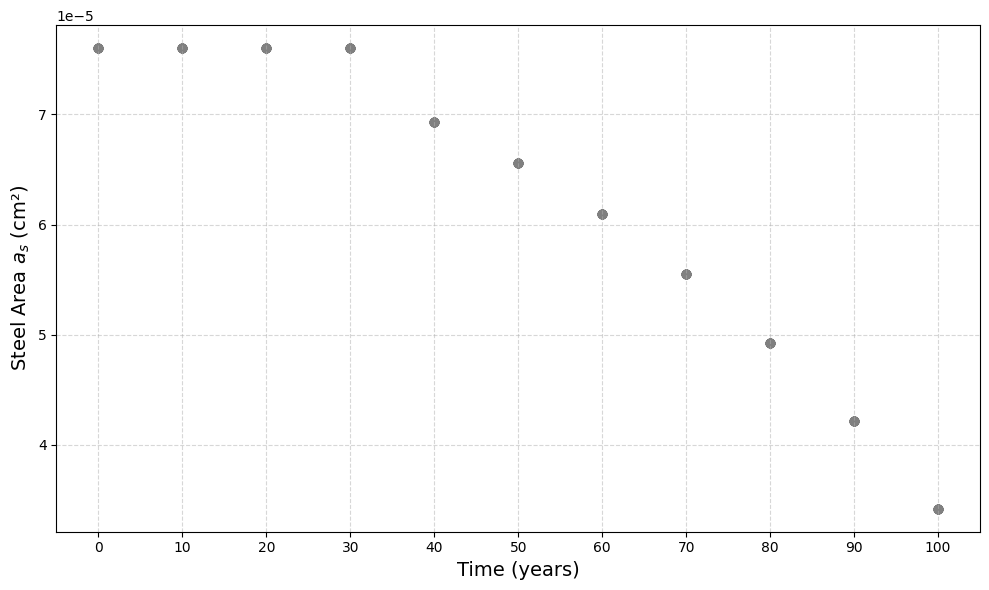

In [16]:
#Time steps (e.g., years or inspection intervals)
x = list(np.arange(0, 101, 10))

# Plotting steel area degradation curves for each simulation
plt.figure(figsize=(10, 6))  # Set figure size (width x height in inches)

for a_s_curve in results_as:
    # Plot each steel area degradation curve in cm²
    plt.scatter(x, a_s_curve, marker='o', linestyle='-', color='gray', alpha=1)

# Plot formatting
plt.xlabel('Time (years)', fontsize=14)
plt.ylabel('Steel Area $a_s$ (cm²)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(x)
plt.tight_layout()

# Show the plot
plt.show()

# Converte a lista para array para facilitar análise
as_array = np.array(results_as)

# Calcula o desvio padrão de cada ponto no tempo
stds = np.std(as_array, axis=0)
